# 

In [1]:
#Load data
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns = data.feature_names)

df['target'] = data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


**DATA PREPROCESSING**

In [2]:
import numpy as np
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [3]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [4]:
#Check for Duplicate Rows
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Length: 569, dtype: bool

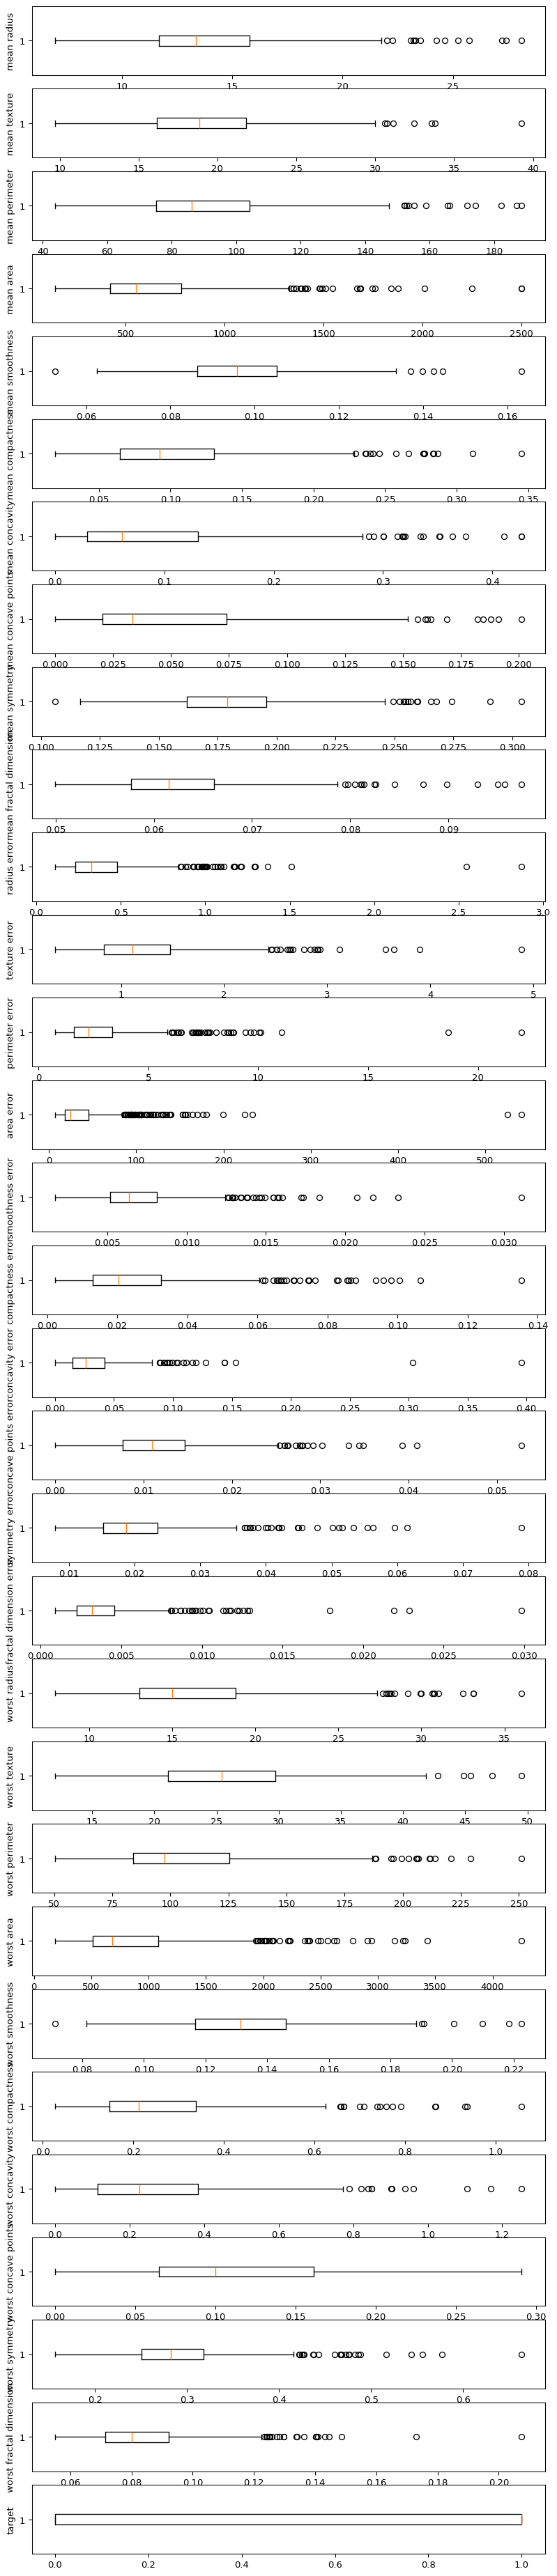

In [5]:
#Statistical summary and visualizing outliers
import matplotlib.pyplot as plt
import seaborn as sns
df.describe()

fig, axs = plt.subplots(len(df.columns), 1, figsize = (10, 50), dpi = 95)
for i, col in enumerate(df.columns):
    axs[i].boxplot(df[col], vert = False)
    axs[i].set_ylabel(col)


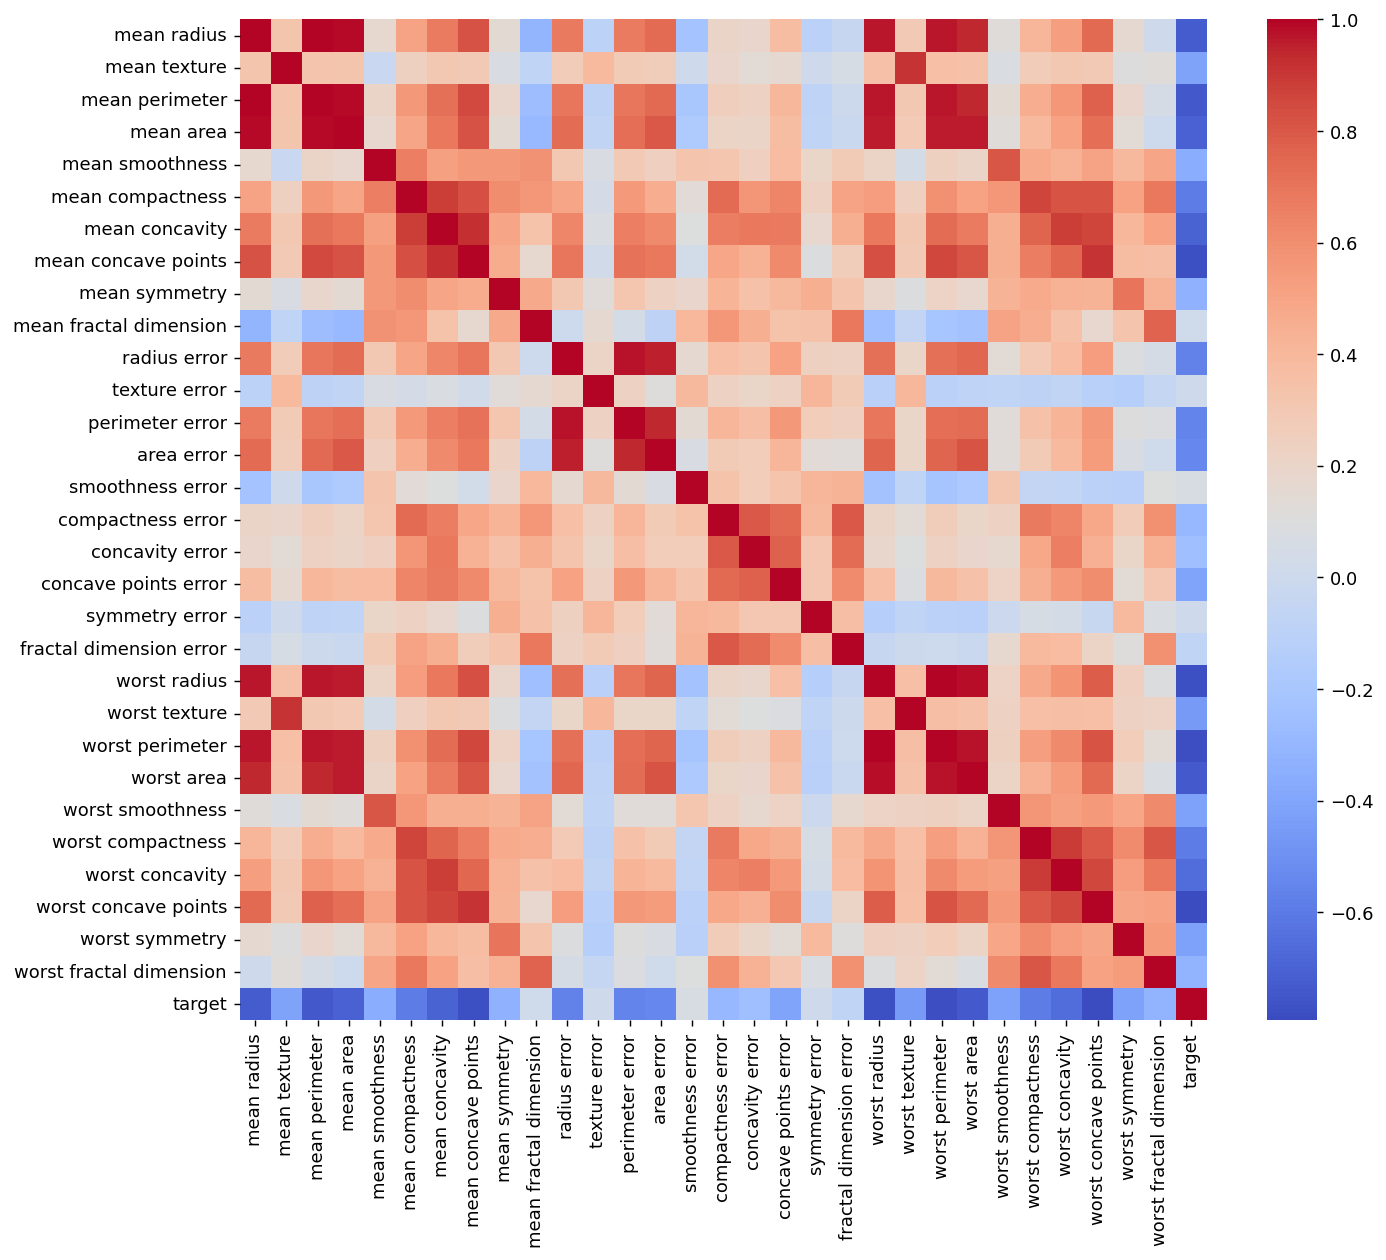

target                     1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
concave points error      -0.408042
mean texture              -0.415185
worst symmetry            -0.416294
worst smoothness          -0.421465
worst texture             -0.456903
area error                -0.548236
perimeter error           -0.556141
radius error              -0.567134
worst compactness         -0.590998
mean compactness          -0.596534
worst concavity           -0.659610
mean concavity            -0.696360
mean area                 -0.708984
mean radius               -0.730029
worst area                -0.733825
mean perimeter            -0.742636
worst radius              -0

In [6]:
#Correlation analysis

# correlation matrix
corr = df.corr()

plt.figure(figsize=(12,10), dpi=130)
sns.heatmap(corr, cmap='coolwarm')
plt.show()

# correlation với target
corr_target = corr["target"].sort_values(ascending=False)
print(corr_target)

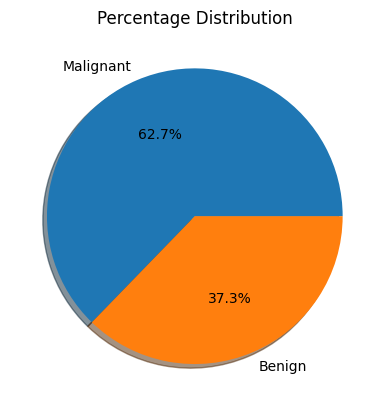

In [7]:
# Visualize target variable distribution
plt.pie(df['target'].value_counts(), autopct ='%1.1f%%', shadow = True, labels = ['Malignant', 'Benign'])
plt.title('Percentage Distribution')
plt.show()

In [8]:
#Splitting dataset 
from sklearn.model_selection import train_test_split

X = df.drop("target", axis = 1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(X_train, '\n', X_test)
print(y_train, '\n', y_test)

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
68         9.029         17.33           58.79      250.5          0.10660   
181       21.090         26.57          142.70     1311.0          0.11410   
63         9.173         13.86           59.20      260.9          0.07721   
248       10.650         25.22           68.01      347.0          0.09657   
60        10.170         14.88           64.55      311.9          0.11340   
..           ...           ...             ...        ...              ...   
71         8.888         14.64           58.79      244.0          0.09783   
106       11.640         18.33           75.17      412.5          0.11420   
270       14.290         16.82           90.30      632.6          0.06429   
435       13.980         19.62           91.12      599.5          0.10600   
102       12.180         20.52           77.22      458.7          0.08013   

     mean compactness  mean concavity  mean concave points  mea

In [9]:
#Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
#Training the model
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter = 10000, random_state = 0)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=10000, random_state=0)

In [11]:
#Evaluation Metrics
from sklearn.metrics import classification_report

print(classification_report(y_test, clf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



ROC-AUC Score: 0.99737962659679


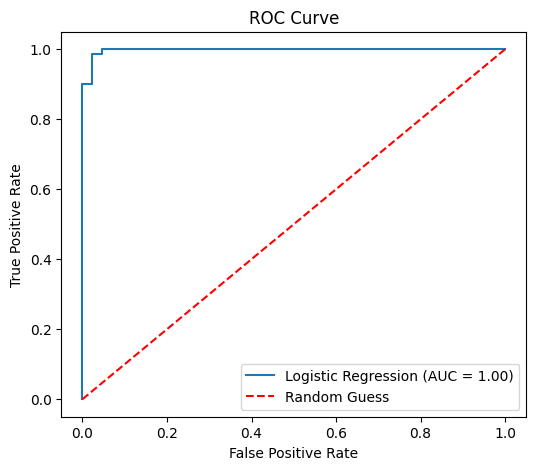

In [12]:
#ROC-AUC
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# Xác suất dự đoán lớp 1 (Benign)
y_prob = clf.predict_proba(X_test)[:, 1]

# Tính ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Tính AUC
roc_auc = auc(fpr, tpr)

# Hoặc dùng trực tiếp
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

# Vẽ biểu đồ
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(LogisticRegression(max_iter=5000),
                    param_grid,
                    cv=5)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=5000),
             param_grid={'C': [0.01, 0.1, 1, 10]})

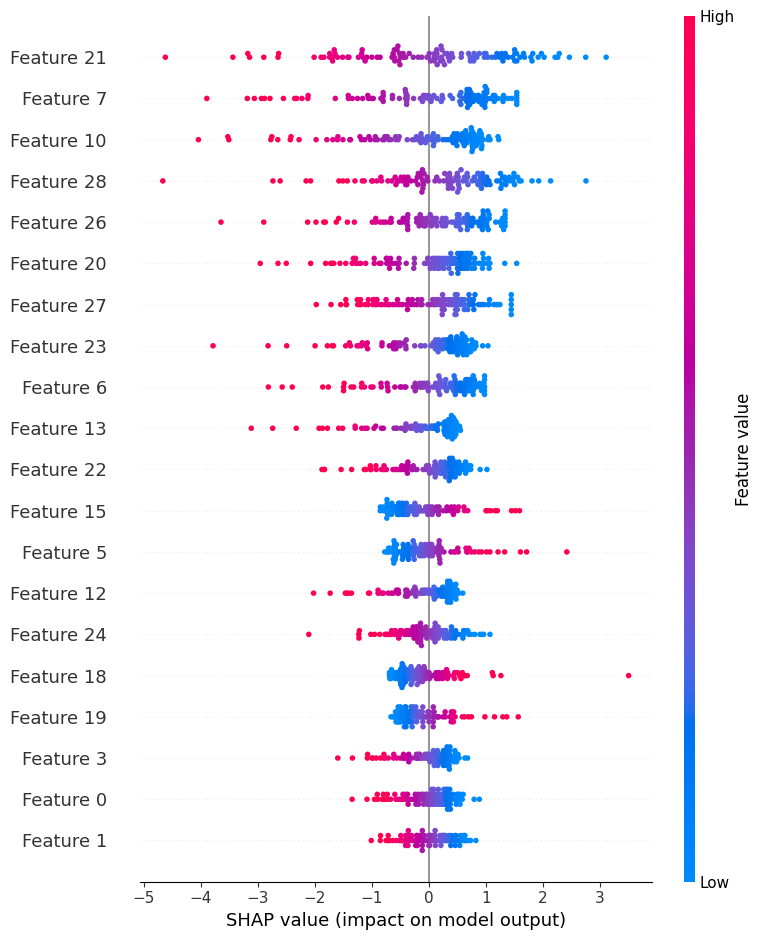

In [14]:
import shap

# Tạo explainer cho mô hình tuyến tính
explainer = shap.LinearExplainer(clf, X_train)

# Tính SHAP values
shap_values = explainer(X_test)

# Vẽ biểu đồ
shap.summary_plot(shap_values, X_test)

In [15]:
# Save model
import joblib

joblib.dump(clf, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [16]:

# Load model & scaler một lần duy nhất
model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")

def predict_patient(features):
    """
    features: list includes 30 values
    """

    # Tạo DataFrame có tên cột
    features_df = pd.DataFrame([features], columns=scaler.feature_names_in_)

    # Scale
    features_scaled = scaler.transform(features_df)

    prediction = model.predict(features_scaled)[0]
    probability = model.predict_proba(features_scaled)[0][1]

    result = "Benign" if prediction == 1 else "Malignant"

    return {
        "prediction": result,
        "probability_class_1": round(float(probability), 4)
    }

In [17]:


# Ví dụ 1 bệnh nhân (30 features)
sample = [
    14.5, 20.3, 95.2, 600.1, 0.10,
    0.15, 0.12, 0.08, 0.18, 0.06,
    0.5, 1.2, 3.1, 25.0, 0.004,
    0.02, 0.03, 0.01, 0.02, 0.003,
    16.5, 25.3, 105.2, 750.1, 0.14,
    0.25, 0.30, 0.15, 0.25, 0.09
]

result = predict_patient(sample)
print(result)

{'prediction': 'Malignant', 'probability_class_1': 0.3611}
